# Positional vs. lexical vs. reflexive binding: an interchange-intervention pilot

A small replication of the central distinction in Gur-Arieh et al. (2025), *Mixing Mechanisms: How Language Models Retrieve Bound Entities In-Context* ([arXiv:2510.06182](https://arxiv.org/abs/2510.06182)), run on a 1.5B instruction-tuned model with `nnsight`.

## The design

A base context lists `n` groups `E_i loves A_i` and asks `Who loves A_k?`, so the answer is `E_k`. A counterfactual context keeps the **same entities at the same positions** but permutes the attributes by `pi`, and queries the attribute now sitting at position `kp`. We copy the residual stream at the final token of the counterfactual run into the same layer and position of the base run.

Three candidate answers are then distinguishable in a single patched forward pass:

| outcome | predicted answer | interpretation |
| --- | --- | --- |
| `E_kp` | entity at the counterfactual's query *index* | positional retrieval |
| `E_pi(kp)` | entity paired in the base with the counterfactual's query *attribute* | lexical retrieval |
| `E_k` | the original base answer | the patch had no effect |

Trials are generated so that these three entities are always distinct, which is what makes the readout a three-way attribution rather than a binary one.

**A constraint worth stating up front:** this is impossible for `n = 2`. With two groups, `kp != k` forces `kp` to be the other index, and requiring `pi(kp) != kp` then forces `pi(kp) == k`, which collides with the base answer. So separating positional from lexical retrieval needs at least three groups. `test_trials.py` asserts this.

**What the design cannot resolve on its own:** a reflexive pointer to the target token predicts the same answer as the positional mechanism, because the entities sit at the same positions in both contexts. The reflexive control below replaces the entity at position `kp` in the base context with a fresh entity `F`. A positional signal then retrieves `F`, whereas a reflexive pointer to `E_kp` has no referent and should fail.

In [1]:
!git -C /content/binding-mechanisms-pilot pull

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 1.70 KiB | 1.71 MiB/s, done.
From https://github.com/lldliys/binding-mechanisms-pilot
   29ffee0..f15b60a  main       -> origin/main
Updating 29ffee0..f15b60a
Fast-forward
 binding_pilot.py | 59 ++++++++++++++++++++++++++++++++++++++++++++------------
 1 file changed, 47 insertions(+), 12 deletions(-)


In [2]:
!pip -q install nnsight transformers accelerate

import os
import subprocess

REPO = "https://github.com/lldliys/binding-mechanisms-pilot.git"

# Fetch binding_pilot.py when running from a bare Colab runtime. Idempotent, so
# re-running this cell after a session restart is safe.
if not os.path.exists("binding_pilot.py"):
    subprocess.run(["git", "clone", "-q", REPO], check=False)
    os.chdir("binding-mechanisms-pilot")

import random

import matplotlib.pyplot as plt
import pandas as pd
import torch

import binding_pilot as bp

os.makedirs("figures", exist_ok=True)
print("working dir:", os.getcwd())

MODEL = "Qwen/Qwen2.5-1.5B-Instruct"  # ungated; Llama-3.2-1B-Instruct also works
BACKEND = "nnsight"
N_GROUPS = 6
N_TRIALS = 24
SEED = 0

runner = bp.Runner(MODEL, dtype="float16", prefer_nnsight=BACKEND == "nnsight")
print(f"{runner.n_layers} layers on {runner.device}, nnsight active: {runner.lm is not None}")

# Candidate-restricted decoding compares whole names, so every name must be a
# single token. Multi-token names would silently turn this into a prefix match.
entities = runner.single_token_words(bp.ENTITY_POOL)
attrs = runner.single_token_words(bp.ATTR_POOL)
print(f"single-token entities {len(entities)}/{len(bp.ENTITY_POOL)}, "
      f"attributes {len(attrs)}/{len(bp.ATTR_POOL)}")
print("dropped entities:", sorted(set(bp.ENTITY_POOL) - set(entities)))
print("dropped attributes:", sorted(set(bp.ATTR_POOL) - set(attrs)))

working dir: /content/binding-mechanisms-pilot


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


nnsight 0.7.0


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

decoder layer returns a bare tensor
nnsight verified against hooks (logits, residuals, patch), max|delta|=0
28 layers on cuda, nnsight active: True
single-token entities 30/30, attributes 20/20
dropped entities: []
dropped attributes: []


In [3]:
rng = random.Random(SEED)
prefix_fn = lambda: bp.few_shot_prefix(rng, entities, attrs, N_GROUPS, n_shot=2)

trials = [bp.make_trial(rng, N_GROUPS, entities, attrs, prefix_fn) for _ in range(N_TRIALS)]

t = trials[0]
print(t.base_prompt)
print("\n--- counterfactual ---\n" + t.cf_prompt.split("\n\n")[-1])
print(f"\nunchanged={t.base_answer}  positional={t.positional}  lexical={t.lexical}")

# The intervention is only interpretable where the model solves the task cleanly.
acc = bp.clean_accuracy(runner, trials, BACKEND)
print(f"\nclean accuracy (n={N_GROUPS}): {acc:.3f}")

# Runner.__init__ already compared the two backends on a clean forward pass.
# Repeat it for a *patched* pass, which is where an off-by-one in the position
# or a mis-scoped hook would actually show up.
if runner.lm is not None:
    _, resid = runner.run(t.cf_prompt, save_resid=True, backend="nnsight")
    mid = runner.n_layers // 2
    a, _ = runner.run(t.base_prompt, patch=(mid, -1, resid[mid]), backend="nnsight")
    b, _ = runner.run(t.base_prompt, patch=(mid, -1, resid[mid]), backend="hooks")
    print(f"nnsight vs hooks, max|delta logits| = {(a - b).abs().max():.2e}")

Joe loves juice. Hugo loves soup. Tess loves fish. Nina loves toast. Nick loves ham. Beth loves milk.
Question: Who loves milk?
Answer: Beth

Iris loves corn. Paul loves tea. Jane loves juice. Beth loves pie. Sam loves jam. Carl loves fish.
Question: Who loves pie?
Answer: Beth

Tess loves pasta. Jack loves salad. Ivan loves eggs. Mia loves milk. Tim loves cheese. Dan loves rice.
Question: Who loves salad?
Answer:

--- counterfactual ---
Tess loves rice. Jack loves pasta. Ivan loves milk. Mia loves salad. Tim loves cheese. Dan loves eggs.
Question: Who loves eggs?
Answer:

unchanged=Jack  positional=Dan  lexical=Ivan

clean accuracy (n=6): 0.917
nnsight vs hooks, max|delta logits| = 0.00e+00


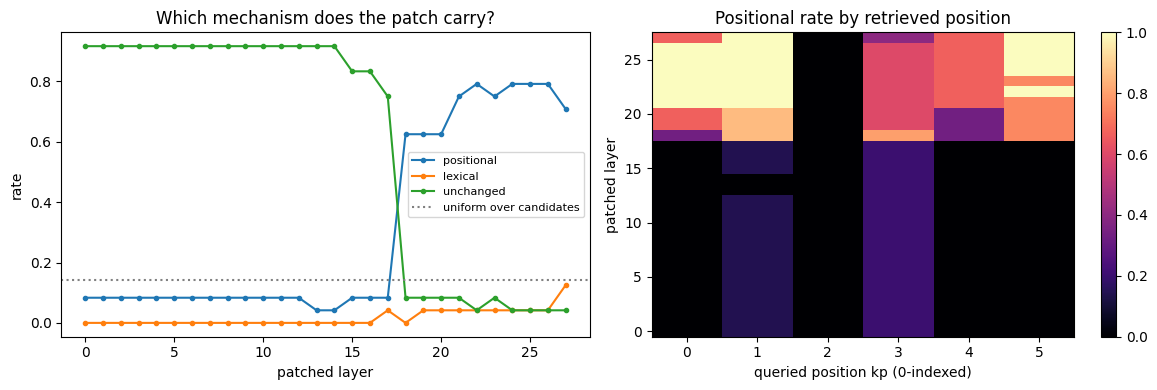

peak positional layer 22: 0.792 positional, 0.042 lexical, 0.042 unchanged

positional rate at edge vs middle positions:
  edges  0.306
  middle 0.311


In [4]:
rows = bp.interchange_sweep(runner, trials, BACKEND)
for r in rows:
    r["positional_name"] = trials[r["trial"]].positional

df = pd.DataFrame(rows)
for name in ("positional", "lexical", "unchanged"):
    df[name] = df.label.eq(name)
by_layer = df.groupby("layer")[["positional", "lexical", "unchanged"]].mean()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
by_layer.plot(ax=ax[0], marker="o", ms=3)
ax[0].set(xlabel="patched layer", ylabel="rate", title="Which mechanism does the patch carry?")
ax[0].axhline(1 / (N_GROUPS + 1), ls=":", c="grey", label="uniform over candidates")
ax[0].legend(fontsize=8)

piv = df.pivot_table(index="layer", columns="kp", values="positional")
im = ax[1].imshow(piv.values, aspect="auto", origin="lower", vmin=0, vmax=1, cmap="magma")
ax[1].set(xlabel="queried position kp (0-indexed)", ylabel="patched layer",
          title="Positional rate by retrieved position")
ax[1].set_xticks(range(len(piv.columns)), piv.columns)
fig.colorbar(im, ax=ax[1])
plt.tight_layout()
plt.savefig("figures/mechanism_rates.png", dpi=150)
plt.show()

peak = int(by_layer.positional.idxmax())
print(f"peak positional layer {peak}: {by_layer.positional[peak]:.3f} positional, "
      f"{by_layer.lexical[peak]:.3f} lexical, {by_layer.unchanged[peak]:.3f} unchanged")
print("\npositional rate at edge vs middle positions:")
edges = df[df.kp.isin([0, N_GROUPS - 1])].positional.mean()
middle = df[~df.kp.isin([0, N_GROUPS - 1])].positional.mean()
print(f"  edges  {edges:.3f}\n  middle {middle:.3f}")

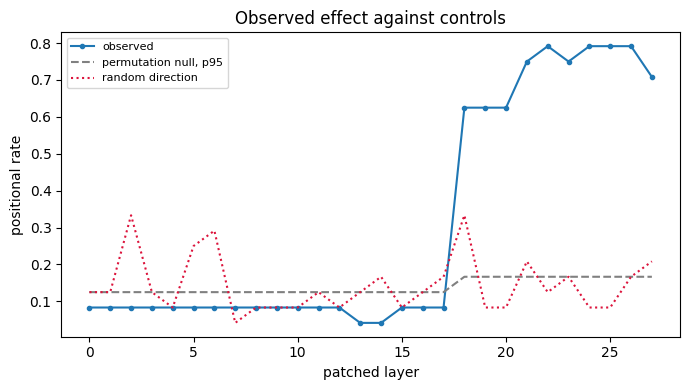

at layer 22, entity at kp intact vs replaced:
  positional  0.792 -> 0.292
  lexical     0.042 -> 0.083


In [5]:
# Control 1: a norm-matched random direction. Anything this reproduces is an
# artefact of perturbing the final token, not of the information we copied.
rand = pd.DataFrame(bp.interchange_sweep(runner, trials, BACKEND, random_patch=True))
rand["positional"] = rand.label.eq("positional")

# Control 2: a permutation null for the positional rate. Shuffling which outcome
# belongs to which trial destroys the pairing while keeping the marginal
# distribution of predicted names, so it prices in name-frequency biases.
null = bp.permutation_null(rows)
null_df = pd.DataFrame(null).T.sort_index()

# Control 3: replace the entity at position kp in the base context. A positional
# signal now retrieves the fresh entity; a reflexive pointer has no referent.
swap = pd.DataFrame(bp.interchange_sweep(runner, trials, BACKEND, swapped=True))
swap["positional"] = swap.label.eq("positional")
swap["lexical"] = swap.label.eq("lexical")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(by_layer.index, by_layer.positional, marker="o", ms=3, label="observed")
ax.plot(null_df.index, null_df.null_p95, ls="--", c="grey", label="permutation null, p95")
ax.plot(rand.groupby("layer").positional.mean(), ls=":", c="crimson", label="random direction")
ax.set(xlabel="patched layer", ylabel="positional rate", title="Observed effect against controls")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/controls.png", dpi=150)
plt.show()

print(f"at layer {peak}, entity at kp intact vs replaced:")
print(f"  positional  {by_layer.positional[peak]:.3f} -> "
      f"{swap[swap.layer.eq(peak)].positional.mean():.3f}")
print(f"  lexical     {by_layer.lexical[peak]:.3f} -> "
      f"{swap[swap.layer.eq(peak)].lexical.mean():.3f}")

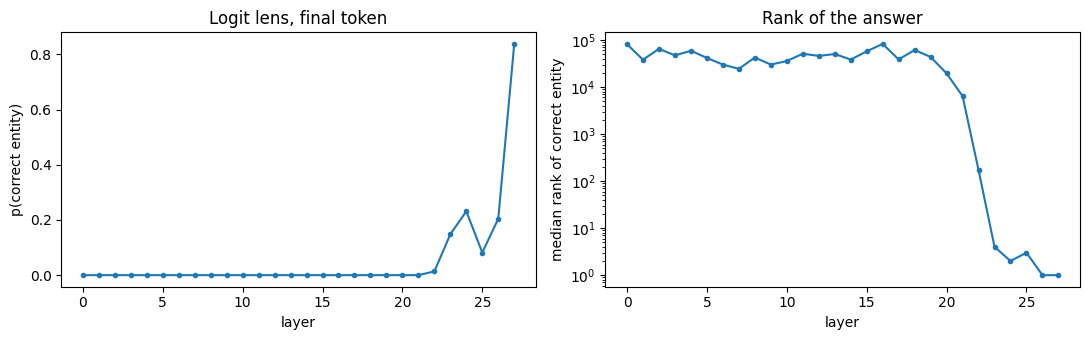

       p_gold  rank_gold
layer                   
0      0.0000    81279.5
1      0.0000    38163.5
2      0.0001    64932.5
3      0.0000    47097.0
4      0.0000    59097.5
5      0.0000    41612.5
6      0.0000    30019.0
7      0.0000    24405.5
8      0.0000    42469.0
9      0.0000    30074.0
10     0.0000    35716.0
11     0.0000    51157.5
12     0.0000    45854.0
13     0.0000    50493.0
14     0.0000    38362.0
15     0.0000    57473.5
16     0.0000    82708.5
17     0.0000    38677.5
18     0.0000    61292.5
19     0.0000    43657.5
20     0.0000    19531.5
21     0.0001     6405.0
22     0.0135      172.0
23     0.1483        4.0
24     0.2314        2.0
25     0.0819        3.0
26     0.2046        0.5
27     0.8378        0.0


In [6]:
# Logit lens on the clean runs: at which depth does the answer become readable
# at the final token? This says where to expect the patch to bite.
lens = pd.DataFrame(bp.logit_lens_curve(runner, trials, BACKEND))
agg = lens.groupby("layer").agg(p_gold=("p_gold", "mean"), rank_gold=("rank_gold", "median"))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(agg.index, agg.p_gold, marker="o", ms=3)
ax[0].set(xlabel="layer", ylabel="p(correct entity)", title="Logit lens, final token")
ax[1].semilogy(agg.index, agg.rank_gold.clip(lower=1), marker="o", ms=3)
ax[1].set(xlabel="layer", ylabel="median rank of correct entity", title="Rank of the answer")
plt.tight_layout()
plt.savefig("figures/logit_lens.png", dpi=150)
plt.show()

print(agg.round(4).to_string())

    positional  lexical  unchanged
kp                                
0        0.889    0.010      0.000
1        0.968    0.000      0.016
2        0.481    0.123      0.111
3        0.741    0.000      0.111
4        0.516    0.016      0.151
5        0.504    0.074      0.096

trials per position: 12
edges 0.667  middle 0.691


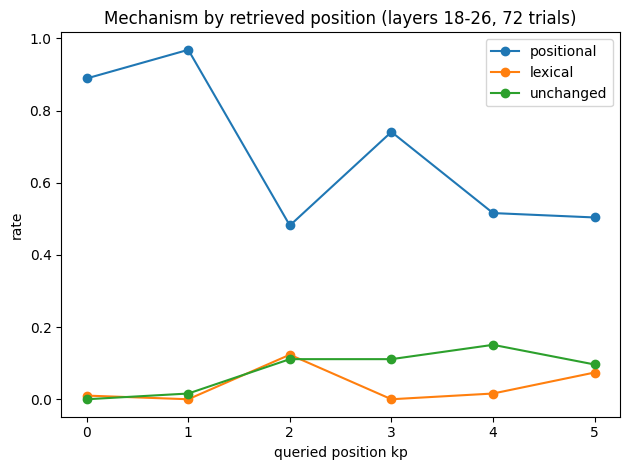

In [7]:
# The edge-vs-middle number above averages over all 28 layers, most of which
# carry no effect, and 24 trials give only ~4 per position. Re-measure inside
# the band where the effect actually lives.
band = list(range(18, 27))
rng2 = random.Random(SEED + 1)
prefix2 = lambda: bp.few_shot_prefix(rng2, entities, attrs, N_GROUPS, n_shot=2)
more = [bp.make_trial(rng2, N_GROUPS, entities, attrs, prefix2) for _ in range(72)]

d2 = pd.DataFrame(bp.interchange_sweep(runner, more, BACKEND, layers=band))
for name in ("positional", "lexical", "unchanged"):
    d2[name] = d2.label.eq(name)

per_pos = d2.groupby("kp")[["positional", "lexical", "unchanged"]].mean()
print(per_pos.round(3).to_string())
print("\ntrials per position:", int(len(d2) / len(band) / N_GROUPS))
e = d2[d2.kp.isin([0, N_GROUPS - 1])].positional.mean()
m = d2[~d2.kp.isin([0, N_GROUPS - 1])].positional.mean()
print(f"edges {e:.3f}  middle {m:.3f}")

per_pos.plot(marker="o")
plt.xlabel("queried position kp"); plt.ylabel("rate")
plt.title(f"Mechanism by retrieved position (layers {band[0]}-{band[-1]}, 72 trials)")
plt.tight_layout(); plt.savefig("figures/by_position.png", dpi=150); plt.show()

In [9]:
import numpy as np

# The edges-vs-middle split lumps kp=0 (0.889) with kp=5 (0.504), which behave
# nothing alike. The real structure is a primacy gradient, so test early vs late.
per_trial = (d2.groupby(["trial", "kp"])[["positional", "lexical", "unchanged"]]
               .mean().reset_index())
grp = per_trial.kp.le(1)
print(per_trial.groupby(grp.map({True: "early kp0-1", False: "late kp2-5"}))
               [["positional", "lexical", "unchanged"]]
               .agg(["mean", "sem", "size"]).round(3).to_string())

x, g = per_trial.positional.values, grp.values
obs = x[g].mean() - x[~g].mean()
null = np.array([(lambda p: x[p].mean() - x[~p].mean())(np.random.permutation(g))
                 for _ in range(10000)])
print(f"\nearly - late = {obs:+.3f}, permutation p = {(np.abs(null) >= abs(obs)).mean():.4f}")

            positional             lexical             unchanged            
                  mean    sem size    mean    sem size      mean    sem size
kp                                                                          
early kp0-1      0.933  0.025   25   0.004  0.004   25     0.009  0.006   25
late kp2-5       0.548  0.061   47   0.052  0.030   47     0.118  0.040   47

early - late = +0.385, permutation p = 0.0000


## What I found

- Clean accuracy at `n = 6` is 0.917, so the model solves the task and the
  interventions are interpretable. The nnsight and hooks backends agree exactly
  (max|delta| = 0 on logits, residuals, and a patched pass).
- Patching the counterfactual's final-token residual is nearly inert below layer
  20 and peaks sharply at layer 22: 79% positional, 4% lexical, 4% unchanged.
- Positional control is not uniform across the list. Averaged over layers 18-26
  with 72 trials, the positional rate is 0.933 (SEM 0.025, n=25 trials) for the
  two list-initial positions versus 0.548 (SEM 0.061, n=47) for the rest; a
  trial-level permutation test over 10,000 relabelings gives a gap of +0.385 at
  p = 1e-4. The edges-versus-middle contrast I first ran is the wrong split: it
  averages the first position together with the last, and those behave nothing
  alike (0.889 vs 0.504).
- Where positional control weakens it does not cleanly hand over to lexical.
  Lexical picks up only 0-12%, while the share of answers matching none of the
  three predictions grows from ~2% at kp=1 to ~30% at kp=4-5, and the
  trial-level variance roughly doubles. The honest reading is that the
  single-vector patch loses control of retrieval for later positions rather than
  that the model switches mechanism. Later items sit closer to the final token,
  so this runs against a simple recency account and I do not have an explanation
  I trust at this scale.

## Limitations I am aware of

- One 1.5B model, one prompt template, 24 trials per condition. The numbers are indicative, not tight.
- I patch the whole residual stream at the final token, so this localises *depth*, not the attention heads that write the signal. Attributing it to heads and asking whether they write into shared or separate subspaces is the next step, and needs DAS rather than plain patching.
- Positional and reflexive retrieval are only separated by the entity-replacement control, which also changes the token distribution of the context. A cleaner separation would keep the entity present but move it.
- Attribute permutation changes the whole context, so the counterfactual differs from the base in more than the queried group. Matched single-swap counterfactuals would be tighter.
- Lexical retrieval stays marginal throughout. That is consistent with the claim
  that it matters more as contexts lengthen, but n = 6 in a 1.5B model may be
  too easy to push the model off the positional/reflexive route.